# ASCON First-Round x′0 CPA/DPA Analysis — Clean 50,000-Trace Dataset

This notebook analyses the clean paper-style ASCON first-round DPA/CPA dataset.

It does:
1. Load the clean 50,000-trace dataset.
2. Run dataset QC.
3. Run **x′0 bit-level CPA/DPA** with 8 candidates per bit position.
4. Save detailed and summary CSV results.
5. Optionally run:
   - trace-count robustness test
   - shuffled-nonce sanity check

Default dataset path:

```text
C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747
```

In [1]:
import os
import json
import time
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Imports OK")

Imports OK


## 1. Set dataset and result folders

In [2]:
ASCON_ROOT = Path(r"C:\Users\thetp\Downloads\ASCON_FYP")

RUN_DIR = Path(r"C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747")

RESULTS_DIR = ASCON_ROOT / "04_Results" / "first_round_dpa" / "clean_50000_x0_cpa_dpa"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

META_PATH = RUN_DIR / "metadata.csv"
CONFIG_PATH = RUN_DIR / "config.json"

TRACE_NPY = RUN_DIR / "traces.npy"
TRACE_NPZ = RUN_DIR / "traces.npz"

assert RUN_DIR.exists(), f"RUN_DIR does not exist: {RUN_DIR}"
assert META_PATH.exists(), f"metadata.csv not found: {META_PATH}"
assert CONFIG_PATH.exists(), f"config.json not found: {CONFIG_PATH}"
assert TRACE_NPY.exists() or TRACE_NPZ.exists(), "Neither traces.npy nor traces.npz found in RUN_DIR"

print("RUN_DIR:", RUN_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("metadata:", META_PATH)
print("config:", CONFIG_PATH)
print("trace file:", TRACE_NPY if TRACE_NPY.exists() else TRACE_NPZ)

RUN_DIR: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747
RESULTS_DIR: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x0_cpa_dpa
metadata: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747\metadata.csv
config: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747\config.json
trace file: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747\traces.npy


In [3]:
metadata = pd.read_csv(META_PATH)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

if TRACE_NPY.exists():
    traces = np.load(TRACE_NPY, mmap_mode="r")
    trace_file_used = TRACE_NPY
else:
    # NPZ cannot be memory-mapped in the same way as NPY.
    # If this is slow or memory-heavy, convert it to NPY first.
    npz = np.load(TRACE_NPZ)
    print("NPZ keys:", npz.files)
    traces = npz[npz.files[0]]
    trace_file_used = TRACE_NPZ

print("Trace file used:", trace_file_used)
print("traces shape:", traces.shape)
print("metadata shape:", metadata.shape)

print("\nConfig:")
for k, v in config.items():
    print(f"  {k}: {v}")

display(metadata.head())

Trace file used: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747\traces.npy
traces shape: (50000, 12000)
metadata shape: (50000, 6)

Config:
  experiment: ASCON first-round DPA fixed-key random-nonce clean trace collection
  firmware_path: C:\Users\thetp\Downloads\ASCON_FYP\01_Firmware\first_round_dpa\simpleserial-ascon-firstround-dpa\simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
  firmware_file: simpleserial-ascon-firstround-dpa-CWLITEXMEGA.hex
  data_base: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa
  fixed_key_hex: 00112233445566778899aabbccddeeff
  nonce_mode: random 16-byte nonce per trace
  num_traces: 50000
  p_command_payload: empty bytearray
  scope_gain_db: 28.05859375
  scope_adc_samples: 12000
  scope_adc_offset: 0
  scope_adc_basic_mode: rising_edge
  scope_clkgen_freq: 7384615.384615385
  scope_adc_src: clkgen_x4
  trigger: tio4
  created_at: 2026-06-16T08:41:46.6

,trace_index,key_hex,nonce_hex,response_hex,capture_ret,trigger_count
0,0,00112233445566778899aabbccddeeff,4324031e2fe9f839ac8b86c5cb693776,a7,False,10880
1,1,00112233445566778899aabbccddeeff,7e9dc2549cb45f8adc5332fb6c12a3ee,e2,False,10880
2,2,00112233445566778899aabbccddeeff,58440bf848bc1a19568928e2d8e227f4,9f,False,10880
3,3,00112233445566778899aabbccddeeff,a26ede44234af84d7cdd09dc50791c4a,03,False,10880
4,4,00112233445566778899aabbccddeeff,5bc8d1c1579c22e47c593fe7bcd9629d,e1,False,10880


## 2. Dataset QC

In [4]:
print("Rows:", len(metadata))
print("Columns:", list(metadata.columns))
print("Missing values:")
print(metadata.isna().sum())

print("\ntrace_index unique:", metadata["trace_index"].nunique())
print("trace_index min/max:", metadata["trace_index"].min(), metadata["trace_index"].max())

print("\nunique keys:", metadata["key_hex"].nunique())
print("fixed key:", metadata["key_hex"].iloc[0])

print("\nunique nonces:", metadata["nonce_hex"].nunique(), "/", len(metadata))
print("duplicate nonces:", len(metadata) - metadata["nonce_hex"].nunique())

print("\ncapture_ret counts:")
print(metadata["capture_ret"].value_counts(dropna=False))

print("\nempty responses:", (metadata["response_hex"].astype(str) == "").sum())
print("unique responses:", metadata["response_hex"].nunique())

print("\ntrigger_count counts:")
print(metadata["trigger_count"].value_counts(dropna=False).head(10))

Rows: 50000
Columns: ['trace_index', 'key_hex', 'nonce_hex', 'response_hex', 'capture_ret', 'trigger_count']
Missing values:
trace_index      0
key_hex          0
nonce_hex        0
response_hex     0
capture_ret      0
trigger_count    0
dtype: int64

trace_index unique: 50000
trace_index min/max: 0 49999

unique keys: 1
fixed key: 00112233445566778899aabbccddeeff

unique nonces: 50000 / 50000
duplicate nonces: 0

capture_ret counts:
capture_ret
False    50000
Name: count, dtype: int64

empty responses: 0
unique responses: 256

trigger_count counts:
trigger_count
10880    50000
Name: count, dtype: int64


qc_traces_shape : (1000, 12000)
sample_min : -0.5
sample_max : 0.3212890625
overall_clipping_fraction : 0.0018289166666666666
median_clipping_per_trace : 0.0018333333333333333
max_clipping_per_trace : 0.0021666666666666666


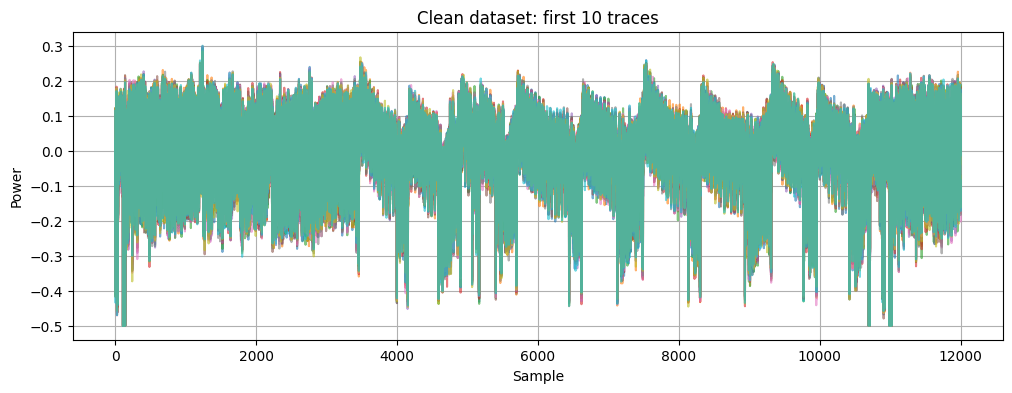

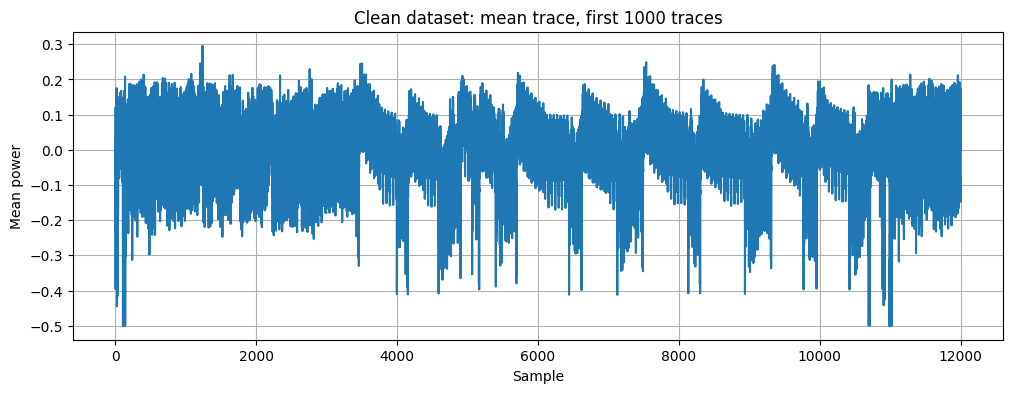

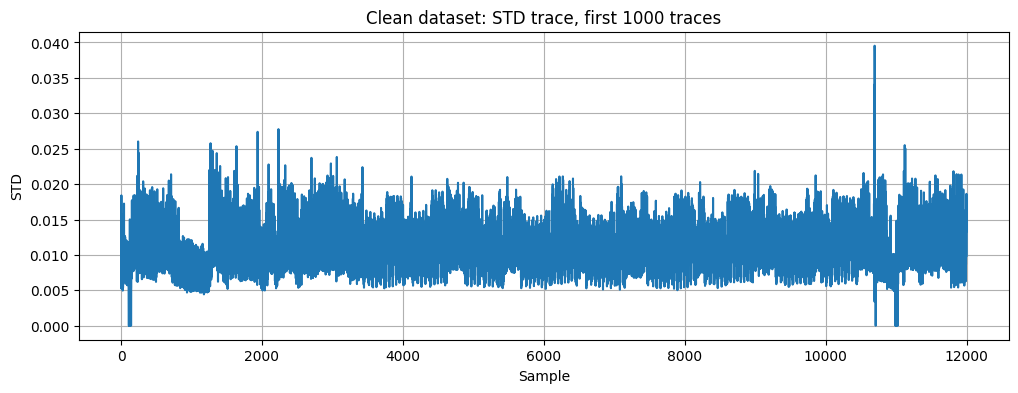

In [5]:
QC_N = min(1000, traces.shape[0])
qc_traces = np.asarray(traces[:QC_N], dtype=np.float32)

sat = ((qc_traces <= -0.49) | (qc_traces >= 0.49))

qc_info = {
    "qc_traces_shape": str(qc_traces.shape),
    "sample_min": float(qc_traces.min()),
    "sample_max": float(qc_traces.max()),
    "overall_clipping_fraction": float(sat.mean()),
    "median_clipping_per_trace": float(np.median(sat.mean(axis=1))),
    "max_clipping_per_trace": float(sat.mean(axis=1).max()),
}

for k, v in qc_info.items():
    print(k, ":", v)

with open(RESULTS_DIR / "dataset_qc_summary.json", "w") as f:
    json.dump(qc_info, f, indent=4)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.plot(qc_traces[i], alpha=0.6)
plt.title("Clean dataset: first 10 traces")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(qc_traces.mean(axis=0))
plt.title("Clean dataset: mean trace, first 1000 traces")
plt.xlabel("Sample")
plt.ylabel("Mean power")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(qc_traces.std(axis=0))
plt.title("Clean dataset: STD trace, first 1000 traces")
plt.xlabel("Sample")
plt.ylabel("STD")
plt.grid(True)
plt.show()

## 3. Analysis settings

Recommended full x′0 analysis:

```python
N_USE = 50000
SAMPLE_START = 0
SAMPLE_END = 12000
SAMPLE_STRIDE = 1
MODES_TO_TEST = ["firmware"]
METHODS_TO_TEST = ["CPA", "DPA"]
```

`firmware` mode is the correct mode for your C implementation because your `LOADBYTES()` is little-endian.

You can set `MODES_TO_TEST = ["firmware", "paper"]` if you want to compare both bit-indexing conventions again.

In [6]:
N_USE = 50000

SAMPLE_START = 0
SAMPLE_END = 12000
SAMPLE_STRIDE = 1

# Keep firmware as default. Add "paper" only if you want comparison again.
MODES_TO_TEST = ["firmware"]

# CPA and DPA both supported.
METHODS_TO_TEST = ["CPA", "DPA"]

BIT_POSITIONS = list(range(64))

# Chunking avoids loading the whole 50000 x 12000 trace matrix into RAM at once.
CHUNK_SAMPLES = 1000

print("N_USE:", N_USE)
print("SAMPLE_START:", SAMPLE_START)
print("SAMPLE_END:", SAMPLE_END)
print("SAMPLE_STRIDE:", SAMPLE_STRIDE)
print("CHUNK_SAMPLES:", CHUNK_SAMPLES)
print("MODES_TO_TEST:", MODES_TO_TEST)
print("METHODS_TO_TEST:", METHODS_TO_TEST)

N_USE: 50000
SAMPLE_START: 0
SAMPLE_END: 12000
SAMPLE_STRIDE: 1
CHUNK_SAMPLES: 1000
MODES_TO_TEST: ['firmware']
METHODS_TO_TEST: ['CPA', 'DPA']


## 4. ASCON little-endian bit helpers

In [7]:
def load64_le_from_bytes(b, offset_bytes):
    x = 0
    for i in range(8):
        x |= int(b[offset_bytes + i]) << (8 * i)
    return x

def load64_le_from_hex(hexstr, offset_bytes):
    b = bytes.fromhex(hexstr)
    return load64_le_from_bytes(b, offset_bytes)

def bit_scalar(x, i):
    return (int(x) >> (i % 64)) & 1

def bits_from_uint64_array(arr, idx):
    return ((arr >> np.uint64(idx % 64)) & np.uint64(1)).astype(np.uint8)

def x0_indices(i, mode):
    if mode == "firmware":
        # Matches your firmware's little-endian ASCON linear layer indexing.
        return [i, i + 19, i + 28]
    elif mode == "paper":
        # Paper notation / alternative index convention.
        return [i, i + 45, i + 36]
    else:
        raise ValueError("mode must be 'firmware' or 'paper'")

def true_x0_candidate(K0, i, mode):
    idxs = x0_indices(i, mode)
    c0 = bit_scalar(K0, idxs[0])
    c1 = bit_scalar(K0, idxs[1])
    c2 = bit_scalar(K0, idxs[2])
    return c0 | (c1 << 1) | (c2 << 2)

def x0_predictions_all_candidates(N0, N1, i, mode):
    """
    Returns P with shape (N, 8), where each column is prediction for candidate 0..7.
    Prediction is binary 0/1.
    """
    idxs = x0_indices(i, mode)

    m0  = bits_from_uint64_array(N0, idxs[0])
    mp0 = bits_from_uint64_array(N1, idxs[0])

    m1  = bits_from_uint64_array(N0, idxs[1])
    mp1 = bits_from_uint64_array(N1, idxs[1])

    m2  = bits_from_uint64_array(N0, idxs[2])
    mp2 = bits_from_uint64_array(N1, idxs[2])

    P = np.zeros((len(N0), 8), dtype=np.uint8)

    for cand in range(8):
        c0 = (cand >> 0) & 1
        c1 = (cand >> 1) & 1
        c2 = (cand >> 2) & 1

        pred = np.zeros(len(N0), dtype=np.uint8)
        pred ^= (c0 & (mp0 ^ 1)) ^ m0
        pred ^= (c1 & (mp1 ^ 1)) ^ m1
        pred ^= (c2 & (mp2 ^ 1)) ^ m2

        P[:, cand] = pred

    return P

fixed_key_hex = metadata["key_hex"].iloc[0]
fixed_key = bytes.fromhex(fixed_key_hex)

K0 = load64_le_from_bytes(fixed_key, 0)
K1 = load64_le_from_bytes(fixed_key, 8)

print("fixed_key_hex:", fixed_key_hex)
print("K0:", hex(K0))
print("K1:", hex(K1))

for mode in ["firmware", "paper"]:
    print(mode, "true x0 candidate bit 0:", true_x0_candidate(K0, 0, mode))

fixed_key_hex: 00112233445566778899aabbccddeeff
K0: 0x7766554433221100
K1: 0xffeeddccbbaa9988
firmware true x0 candidate bit 0: 4
paper true x0 candidate bit 0: 0


In [8]:
def prepare_nonce_words(metadata_df, shuffle_nonce=False, seed=12345):
    nonce_hex = metadata_df["nonce_hex"].astype(str).to_numpy().copy()

    if shuffle_nonce:
        rng = np.random.default_rng(seed)
        rng.shuffle(nonce_hex)

    N0 = np.array([load64_le_from_hex(nh, 0) for nh in nonce_hex], dtype=np.uint64)
    N1 = np.array([load64_le_from_hex(nh, 8) for nh in nonce_hex], dtype=np.uint64)

    return N0, N1

metadata_use = metadata.iloc[:N_USE].copy().reset_index(drop=True)
N0, N1 = prepare_nonce_words(metadata_use, shuffle_nonce=False)

print("N0 shape:", N0.shape)
print("N1 shape:", N1.shape)
print("First nonce:", metadata_use["nonce_hex"].iloc[0])
print("First N0:", hex(int(N0[0])))
print("First N1:", hex(int(N1[0])))

N0 shape: (50000,)
N1 shape: (50000,)
First nonce: 4324031e2fe9f839ac8b86c5cb693776
First N0: 0x39f8e92f1e032443
First N1: 0x763769cbc5868bac


## 5. Chunked CPA/DPA scoring

In [9]:
def update_best(best_scores, best_samples_local, candidate_scores_chunk, sample_indices_chunk):
    """
    Update best max-absolute score and sample index for each candidate.
    candidate_scores_chunk: shape (8, chunk_samples)
    sample_indices_chunk: original sample indices for chunk
    """
    abs_scores = np.abs(candidate_scores_chunk)
    local_argmax = np.argmax(abs_scores, axis=1)
    local_best = abs_scores[np.arange(abs_scores.shape[0]), local_argmax]

    better = local_best > best_scores
    best_scores[better] = local_best[better]
    best_samples_local[better] = sample_indices_chunk[local_argmax[better]]

def score_candidates_chunked(P, traces_obj, sample_indices, methods=("CPA", "DPA"), chunk_samples=1000):
    """
    P: binary predictions, shape (N, 8)
    traces_obj: memmap or ndarray, shape (N_total, S_total)
    sample_indices: selected original sample indices
    """
    N = P.shape[0]
    C = P.shape[1]

    P_float = P.astype(np.float32)

    results = {}

    if "CPA" in methods:
        P_centered = P_float - P_float.mean(axis=0, keepdims=True)
        p_energy = np.sum(P_centered * P_centered, axis=0)
        cpa_best_scores = np.full(C, -np.inf, dtype=np.float64)
        cpa_best_samples = np.full(C, -1, dtype=np.int64)

    if "DPA" in methods:
        count1 = P_float.sum(axis=0)
        count0 = N - count1
        count1_safe = np.maximum(count1, 1)
        count0_safe = np.maximum(count0, 1)
        dpa_best_scores = np.full(C, -np.inf, dtype=np.float64)
        dpa_best_samples = np.full(C, -1, dtype=np.int64)

    for start in range(0, len(sample_indices), chunk_samples):
        idx_chunk = sample_indices[start:start + chunk_samples]

        # Load only this sample chunk.
        T = np.asarray(traces_obj[:N, idx_chunk], dtype=np.float32)

        if "CPA" in methods:
            T_centered = T - T.mean(axis=0, keepdims=True)
            t_energy = np.sum(T_centered * T_centered, axis=0)

            numerator = P_centered.T @ T_centered
            denom = np.sqrt(p_energy[:, None] * t_energy[None, :]) + 1e-12
            corr = numerator / denom

            update_best(cpa_best_scores, cpa_best_samples, corr, idx_chunk)

        if "DPA" in methods:
            sum1 = P_float.T @ T
            total = T.sum(axis=0, keepdims=True)
            sum0 = total - sum1

            mean1 = sum1 / count1_safe[:, None]
            mean0 = sum0 / count0_safe[:, None]
            diff = mean1 - mean0

            update_best(dpa_best_scores, dpa_best_samples, diff, idx_chunk)

    if "CPA" in methods:
        results["CPA"] = {
            "scores": cpa_best_scores,
            "best_samples": cpa_best_samples
        }

    if "DPA" in methods:
        results["DPA"] = {
            "scores": dpa_best_scores,
            "best_samples": dpa_best_samples
        }

    return results

print("Scoring functions ready")

Scoring functions ready


## 6. Run x′0 CPA/DPA analysis

In [10]:
def run_x0_analysis(
    traces_obj,
    metadata_df,
    N_USE,
    sample_start=0,
    sample_end=None,
    sample_stride=1,
    modes=("firmware",),
    methods=("CPA", "DPA"),
    bit_positions=range(64),
    chunk_samples=1000,
    shuffle_nonce=False,
    shuffle_seed=12345,
    label="x0_analysis"
):
    if sample_end is None:
        sample_end = traces_obj.shape[1]

    sample_indices = np.arange(sample_start, sample_end, sample_stride)

    metadata_use = metadata_df.iloc[:N_USE].copy().reset_index(drop=True)
    N0_use, N1_use = prepare_nonce_words(metadata_use, shuffle_nonce=shuffle_nonce, seed=shuffle_seed)

    rows = []
    t0 = time.time()

    for mode in modes:
        print("\nMode:", mode, "| shuffle_nonce:", shuffle_nonce)

        for bit_i in bit_positions:
            P = x0_predictions_all_candidates(N0_use, N1_use, bit_i, mode)
            true_cand = true_x0_candidate(K0, bit_i, mode)

            score_result = score_candidates_chunked(
                P=P,
                traces_obj=traces_obj,
                sample_indices=sample_indices,
                methods=methods,
                chunk_samples=chunk_samples
            )

            for method in methods:
                scores = score_result[method]["scores"]
                best_samples = score_result[method]["best_samples"]

                order = np.argsort(scores)[::-1]
                true_rank = int(np.where(order == true_cand)[0][0]) + 1
                best_cand = int(order[0])

                rows.append({
                    "label": label,
                    "target": "x0_prime",
                    "mode": mode,
                    "method": method,
                    "shuffle_nonce": bool(shuffle_nonce),
                    "N_USE": int(N_USE),
                    "sample_start": int(sample_start),
                    "sample_end": int(sample_end),
                    "sample_stride": int(sample_stride),
                    "bit_i": int(bit_i),
                    "true_candidate": int(true_cand),
                    "best_candidate": int(best_cand),
                    "true_rank": int(true_rank),
                    "best_score": float(scores[best_cand]),
                    "true_score": float(scores[true_cand]),
                    "best_sample_original": int(best_samples[best_cand]),
                    "true_best_sample_original": int(best_samples[true_cand]),
                    "candidate_scores": scores.tolist()
                })

            if bit_i % 8 == 0:
                elapsed = time.time() - t0
                print(f"  bit {bit_i:02d} done | elapsed {elapsed:.1f}s")

    df = pd.DataFrame(rows)
    return df

print("run_x0_analysis ready")

run_x0_analysis ready


In [11]:
RUN_FULL_X0 = True

if not RUN_FULL_X0:
    print("Full x′0 analysis disabled.")
else:
    full_results_df = run_x0_analysis(
        traces_obj=traces,
        metadata_df=metadata,
        N_USE=N_USE,
        sample_start=SAMPLE_START,
        sample_end=SAMPLE_END,
        sample_stride=SAMPLE_STRIDE,
        modes=MODES_TO_TEST,
        methods=METHODS_TO_TEST,
        bit_positions=BIT_POSITIONS,
        chunk_samples=CHUNK_SAMPLES,
        shuffle_nonce=False,
        label="clean_50000_x0"
    )

    display(full_results_df.head())
    print("Result shape:", full_results_df.shape)


Mode: firmware | shuffle_nonce: False
  bit 00 done | elapsed 5.8s
  bit 08 done | elapsed 46.4s
  bit 16 done | elapsed 87.3s
  bit 24 done | elapsed 128.0s
  bit 32 done | elapsed 169.2s
  bit 40 done | elapsed 210.3s
  bit 48 done | elapsed 251.5s
  bit 56 done | elapsed 292.5s


,label,target,mode,method,shuffle_nonce,N_USE,sample_start,sample_end,sample_stride,bit_i,true_candidate,best_candidate,true_rank,best_score,true_score,best_sample_original,true_best_sample_original,candidate_scores
0,clean_50000_x0,x0_prime,firmware,CPA,False,50000,0,12000,1,0,4,4,1,0.226388,0.226388,11131,11131,"[0.017304135486483574, 0.01522328145802021, 0...."
1,clean_50000_x0,x0_prime,firmware,DPA,False,50000,0,12000,1,0,4,4,1,0.010325,0.010325,11130,11130,"[0.000680282711982727, 0.00043555721640586853,..."
2,clean_50000_x0,x0_prime,firmware,CPA,False,50000,0,12000,1,1,4,4,1,0.213406,0.213406,11131,11131,"[0.018043924123048782, 0.01797705516219139, 0...."
3,clean_50000_x0,x0_prime,firmware,DPA,False,50000,0,12000,1,1,4,4,1,0.009565,0.009565,11130,11130,"[0.00044894497841596603, 0.000661410391330719,..."
4,clean_50000_x0,x0_prime,firmware,CPA,False,50000,0,12000,1,2,2,2,1,0.243428,0.243428,4805,4805,"[0.01840069703757763, 0.017136821523308754, 0...."


Result shape: (128, 18)


In [12]:
if RUN_FULL_X0:
    summary_rows = []

    for (mode, method, shuffle_nonce), df in full_results_df.groupby(["mode", "method", "shuffle_nonce"]):
        summary_rows.append({
            "label": df["label"].iloc[0],
            "mode": mode,
            "method": method,
            "shuffle_nonce": shuffle_nonce,
            "N_USE": int(df["N_USE"].iloc[0]),
            "sample_start": int(df["sample_start"].iloc[0]),
            "sample_end": int(df["sample_end"].iloc[0]),
            "sample_stride": int(df["sample_stride"].iloc[0]),
            "rank1_count_out_of_64": int((df["true_rank"] == 1).sum()),
            "rank_le_2_out_of_64": int((df["true_rank"] <= 2).sum()),
            "rank_le_4_out_of_64": int((df["true_rank"] <= 4).sum()),
            "average_true_rank": float(df["true_rank"].mean()),
            "median_true_rank": float(df["true_rank"].median()),
            "mean_best_score": float(df["best_score"].mean()),
            "mean_true_score": float(df["true_score"].mean())
        })

    full_summary_df = pd.DataFrame(summary_rows)
    display(full_summary_df)

    suffix = f"N{N_USE}_samples{SAMPLE_START}_{SAMPLE_END}_stride{SAMPLE_STRIDE}"
    results_csv = RESULTS_DIR / f"x0_clean_cpa_dpa_results_{suffix}.csv"
    summary_csv = RESULTS_DIR / f"x0_clean_cpa_dpa_summary_{suffix}.csv"

    full_results_df.to_csv(results_csv, index=False)
    full_summary_df.to_csv(summary_csv, index=False)

    print("Saved detailed results:", results_csv)
    print("Saved summary:", summary_csv)

,label,mode,method,shuffle_nonce,N_USE,sample_start,sample_end,sample_stride,rank1_count_out_of_64,rank_le_2_out_of_64,rank_le_4_out_of_64,average_true_rank,median_true_rank,mean_best_score,mean_true_score
0,clean_50000_x0,firmware,CPA,False,50000,0,12000,1,64,64,64,1.0,1.0,0.242176,0.242176
1,clean_50000_x0,firmware,DPA,False,50000,0,12000,1,64,64,64,1.0,1.0,0.008305,0.008305


Saved detailed results: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x0_cpa_dpa\x0_clean_cpa_dpa_results_N50000_samples0_12000_stride1.csv
Saved summary: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x0_cpa_dpa\x0_clean_cpa_dpa_summary_N50000_samples0_12000_stride1.csv


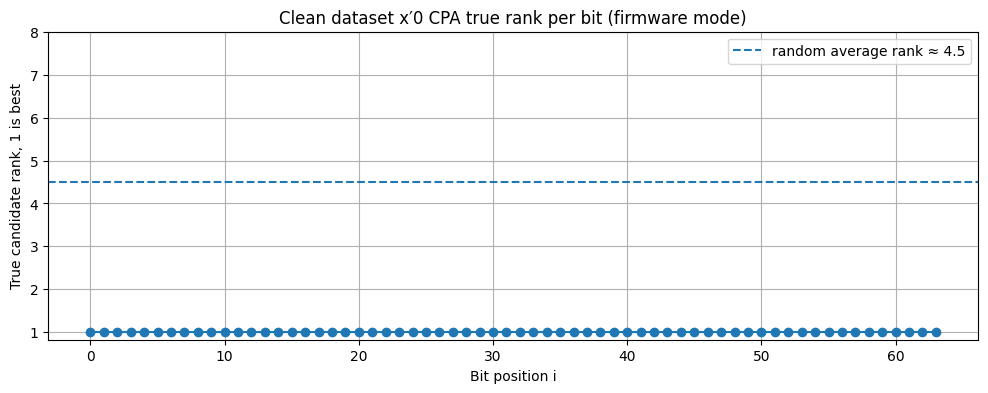

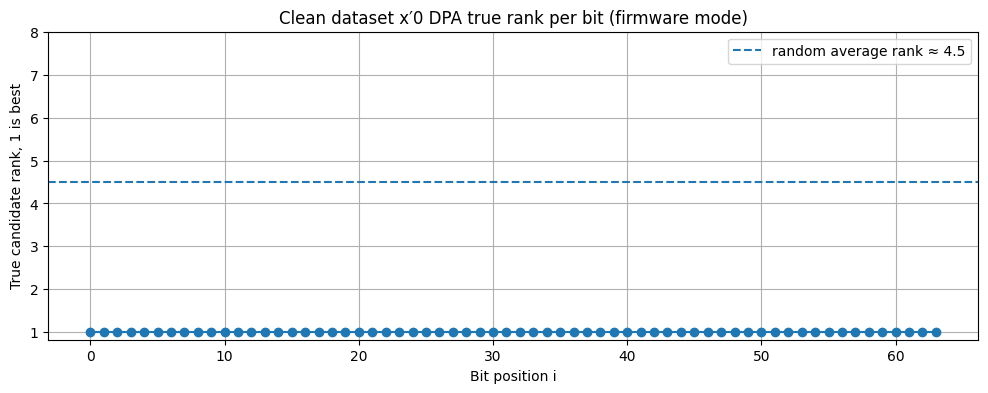

In [13]:
if RUN_FULL_X0:
    for mode in full_results_df["mode"].unique():
        for method in full_results_df["method"].unique():
            df = full_results_df[(full_results_df["mode"] == mode) & (full_results_df["method"] == method)].sort_values("bit_i")

            plt.figure(figsize=(12, 4))
            plt.plot(df["bit_i"], df["true_rank"], marker="o")
            plt.axhline(4.5, linestyle="--", label="random average rank ≈ 4.5")
            plt.title(f"Clean dataset x′0 {method} true rank per bit ({mode} mode)")
            plt.xlabel("Bit position i")
            plt.ylabel("True candidate rank, 1 is best")
            plt.yticks(range(1, 9))
            plt.grid(True)
            plt.legend()
            plt.show()

## 7. Optional trace-count robustness test

This shows how many traces are needed.

Recommended trace counts:

```python
TRACE_COUNTS = list(range(500, 1001, 50)) + list(range(1100, 2001, 100))
```

This may take time. It is disabled by default.


Running robustness N = 500

Mode: firmware | shuffle_nonce: False
  bit 00 done | elapsed 0.0s
  bit 08 done | elapsed 0.2s
  bit 16 done | elapsed 0.5s
  bit 24 done | elapsed 0.7s
  bit 32 done | elapsed 0.9s
  bit 40 done | elapsed 1.2s
  bit 48 done | elapsed 1.4s
  bit 56 done | elapsed 1.6s

Running robustness N = 550

Mode: firmware | shuffle_nonce: False
  bit 00 done | elapsed 0.0s
  bit 08 done | elapsed 0.3s
  bit 16 done | elapsed 0.6s
  bit 24 done | elapsed 0.8s
  bit 32 done | elapsed 1.1s
  bit 40 done | elapsed 1.3s
  bit 48 done | elapsed 1.6s
  bit 56 done | elapsed 1.8s

Running robustness N = 600

Mode: firmware | shuffle_nonce: False
  bit 00 done | elapsed 0.0s
  bit 08 done | elapsed 0.3s
  bit 16 done | elapsed 0.6s
  bit 24 done | elapsed 0.8s
  bit 32 done | elapsed 1.1s
  bit 40 done | elapsed 1.4s
  bit 48 done | elapsed 1.7s
  bit 56 done | elapsed 1.9s

Running robustness N = 650

Mode: firmware | shuffle_nonce: False
  bit 00 done | elapsed 0.0s
  bit 0

,label,N_USE,mode,method,rank1_count_out_of_64,rank_le_2_out_of_64,rank_le_4_out_of_64,average_true_rank,median_true_rank
22,robustness_N500,500,firmware,CPA,58,62,63,1.156250,1.0
24,robustness_N550,550,firmware,CPA,61,62,64,1.078125,1.0
26,robustness_N600,600,firmware,CPA,64,64,64,1.000000,1.0
28,robustness_N650,650,firmware,CPA,64,64,64,1.000000,1.0
30,robustness_N700,700,firmware,CPA,64,64,64,1.000000,1.0
32,robustness_N750,750,firmware,CPA,63,63,64,1.031250,1.0
34,robustness_N800,800,firmware,CPA,64,64,64,1.000000,1.0
36,robustness_N850,850,firmware,CPA,64,64,64,1.000000,1.0
38,robustness_N900,900,firmware,CPA,64,64,64,1.000000,1.0
40,robustness_N950,950,firmware,CPA,63,64,64,1.015625,1.0


Saved robustness results: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x0_cpa_dpa\x0_trace_count_robustness_results_stride1.csv
Saved robustness summary: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x0_cpa_dpa\x0_trace_count_robustness_summary_stride1.csv


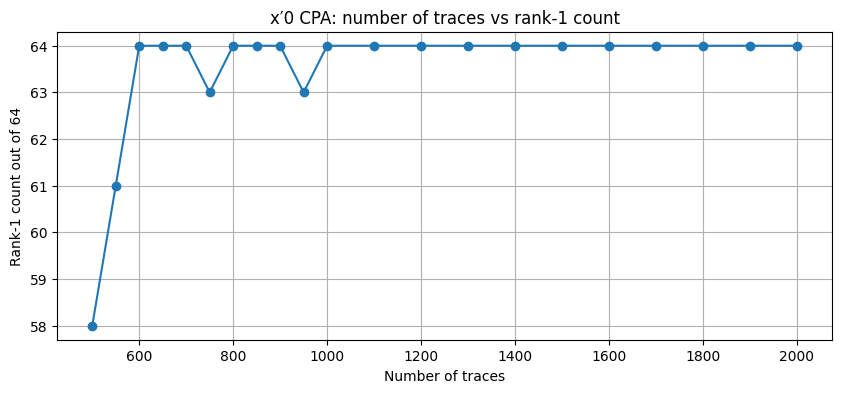

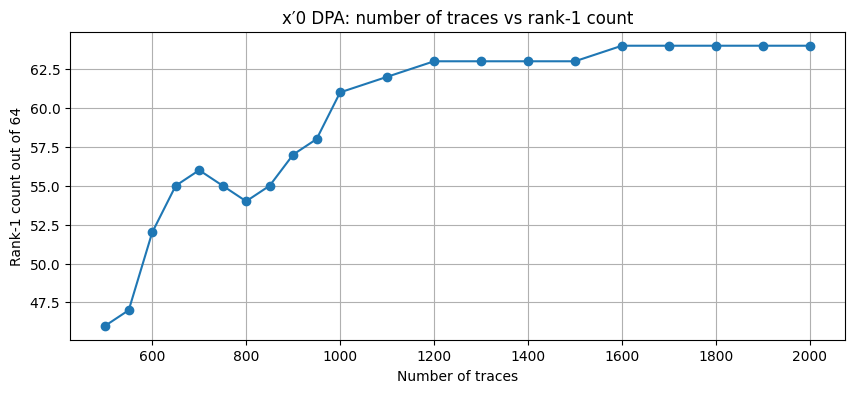

In [14]:
RUN_ROBUSTNESS = True

TRACE_COUNTS = list(range(500, 1001, 50)) + list(range(1100, 2001, 100))

# To save time, you may use stride 2 first. For final robustness, use stride 1.
ROBUSTNESS_SAMPLE_STRIDE = 1
ROBUSTNESS_MODES = ["firmware"]
ROBUSTNESS_METHODS = ["CPA", "DPA"]

if not RUN_ROBUSTNESS:
    print("Robustness test disabled.")
    print("Set RUN_ROBUSTNESS = True to run it.")
else:
    robustness_all = []

    for n in TRACE_COUNTS:
        print("\n" + "=" * 80)
        print("Running robustness N =", n)
        print("=" * 80)

        df_n = run_x0_analysis(
            traces_obj=traces,
            metadata_df=metadata,
            N_USE=n,
            sample_start=0,
            sample_end=traces.shape[1],
            sample_stride=ROBUSTNESS_SAMPLE_STRIDE,
            modes=ROBUSTNESS_MODES,
            methods=ROBUSTNESS_METHODS,
            bit_positions=BIT_POSITIONS,
            chunk_samples=CHUNK_SAMPLES,
            shuffle_nonce=False,
            label=f"robustness_N{n}"
        )

        robustness_all.append(df_n)

    robustness_df = pd.concat(robustness_all, ignore_index=True)

    robustness_summary_rows = []
    for (label, mode, method), df in robustness_df.groupby(["label", "mode", "method"]):
        robustness_summary_rows.append({
            "label": label,
            "N_USE": int(df["N_USE"].iloc[0]),
            "mode": mode,
            "method": method,
            "rank1_count_out_of_64": int((df["true_rank"] == 1).sum()),
            "rank_le_2_out_of_64": int((df["true_rank"] <= 2).sum()),
            "rank_le_4_out_of_64": int((df["true_rank"] <= 4).sum()),
            "average_true_rank": float(df["true_rank"].mean()),
            "median_true_rank": float(df["true_rank"].median()),
        })

    robustness_summary_df = pd.DataFrame(robustness_summary_rows).sort_values(["method", "N_USE"])

    display(robustness_summary_df)

    robustness_csv = RESULTS_DIR / f"x0_trace_count_robustness_results_stride{ROBUSTNESS_SAMPLE_STRIDE}.csv"
    robustness_summary_csv = RESULTS_DIR / f"x0_trace_count_robustness_summary_stride{ROBUSTNESS_SAMPLE_STRIDE}.csv"

    robustness_df.to_csv(robustness_csv, index=False)
    robustness_summary_df.to_csv(robustness_summary_csv, index=False)

    print("Saved robustness results:", robustness_csv)
    print("Saved robustness summary:", robustness_summary_csv)

    for method in ROBUSTNESS_METHODS:
        dfp = robustness_summary_df[robustness_summary_df["method"] == method].sort_values("N_USE")
        plt.figure(figsize=(10, 4))
        plt.plot(dfp["N_USE"], dfp["rank1_count_out_of_64"], marker="o")
        plt.title(f"x′0 {method}: number of traces vs rank-1 count")
        plt.xlabel("Number of traces")
        plt.ylabel("Rank-1 count out of 64")
        plt.grid(True)
        plt.show()

## 8. Optional shuffled-nonce sanity check

This checks whether the CPA/DPA result is real.

Expected after shuffling nonces:
- Rank-1 count should drop near random level, around `8 / 64`.
- Average rank should be close to `4.5`.

If shuffled nonces still give very high rank-1 counts, there may be an analysis bug.

In [15]:
RUN_SHUFFLE_CHECK = False

SHUFFLE_N_USE = 50000
SHUFFLE_SAMPLE_STRIDE = 1
SHUFFLE_MODES = ["firmware"]
SHUFFLE_METHODS = ["CPA", "DPA"]
SHUFFLE_SEED = 20260616

if not RUN_SHUFFLE_CHECK:
    print("Shuffle sanity check disabled.")
    print("Set RUN_SHUFFLE_CHECK = True to run it.")
else:
    shuffle_df = run_x0_analysis(
        traces_obj=traces,
        metadata_df=metadata,
        N_USE=SHUFFLE_N_USE,
        sample_start=0,
        sample_end=traces.shape[1],
        sample_stride=SHUFFLE_SAMPLE_STRIDE,
        modes=SHUFFLE_MODES,
        methods=SHUFFLE_METHODS,
        bit_positions=BIT_POSITIONS,
        chunk_samples=CHUNK_SAMPLES,
        shuffle_nonce=True,
        shuffle_seed=SHUFFLE_SEED,
        label=f"shuffle_N{SHUFFLE_N_USE}"
    )

    shuffle_summary_rows = []
    for (mode, method), df in shuffle_df.groupby(["mode", "method"]):
        shuffle_summary_rows.append({
            "label": df["label"].iloc[0],
            "mode": mode,
            "method": method,
            "N_USE": int(df["N_USE"].iloc[0]),
            "shuffle_nonce": True,
            "rank1_count_out_of_64": int((df["true_rank"] == 1).sum()),
            "rank_le_2_out_of_64": int((df["true_rank"] <= 2).sum()),
            "rank_le_4_out_of_64": int((df["true_rank"] <= 4).sum()),
            "average_true_rank": float(df["true_rank"].mean()),
            "median_true_rank": float(df["true_rank"].median()),
        })

    shuffle_summary_df = pd.DataFrame(shuffle_summary_rows)
    display(shuffle_summary_df)

    shuffle_csv = RESULTS_DIR / f"x0_shuffle_sanity_results_N{SHUFFLE_N_USE}.csv"
    shuffle_summary_csv = RESULTS_DIR / f"x0_shuffle_sanity_summary_N{SHUFFLE_N_USE}.csv"

    shuffle_df.to_csv(shuffle_csv, index=False)
    shuffle_summary_df.to_csv(shuffle_summary_csv, index=False)

    print("Saved shuffle results:", shuffle_csv)
    print("Saved shuffle summary:", shuffle_summary_csv)

Shuffle sanity check disabled.
Set RUN_SHUFFLE_CHECK = True to run it.


Using existing qc_traces from notebook.


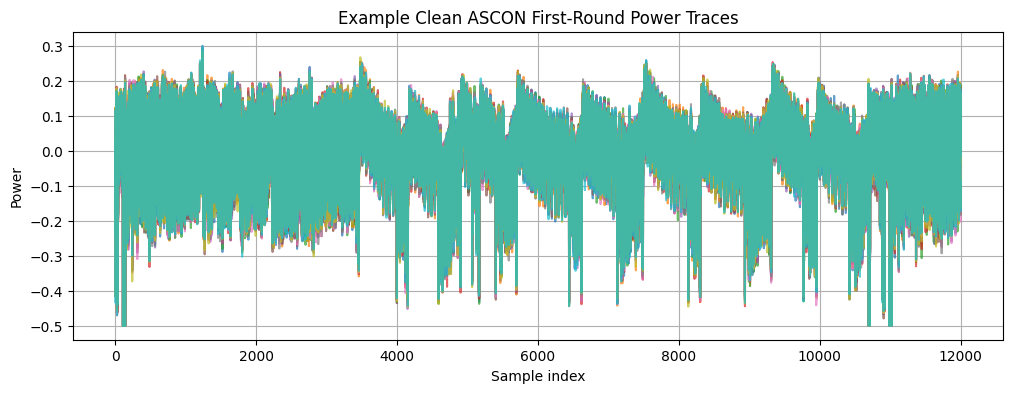

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x0_cpa_dpa\figures\fig1_clean_first_10_traces.png


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = Path(r"C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747")

RESULTS_DIR = Path(r"C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x0_cpa_dpa")
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Use existing qc_traces if already loaded from the QC cell.
# Otherwise, load first 1000 traces.
try:
    qc_traces
    print("Using existing qc_traces from notebook.")
except NameError:
    trace_npy = RUN_DIR / "traces.npy"
    trace_npz = RUN_DIR / "traces.npz"

    if trace_npy.exists():
        traces = np.load(trace_npy, mmap_mode="r")
        qc_traces = np.asarray(traces[:1000], dtype=np.float32)
    else:
        data = np.load(trace_npz)
        print("NPZ keys:", data.files)
        qc_traces = np.asarray(data[data.files[0]][:1000], dtype=np.float32)

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.plot(qc_traces[i], alpha=0.7)

plt.title("Example Clean ASCON First-Round Power Traces")
plt.xlabel("Sample index")
plt.ylabel("Power")
plt.grid(True)

out = FIG_DIR / "fig1_clean_first_10_traces.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out)

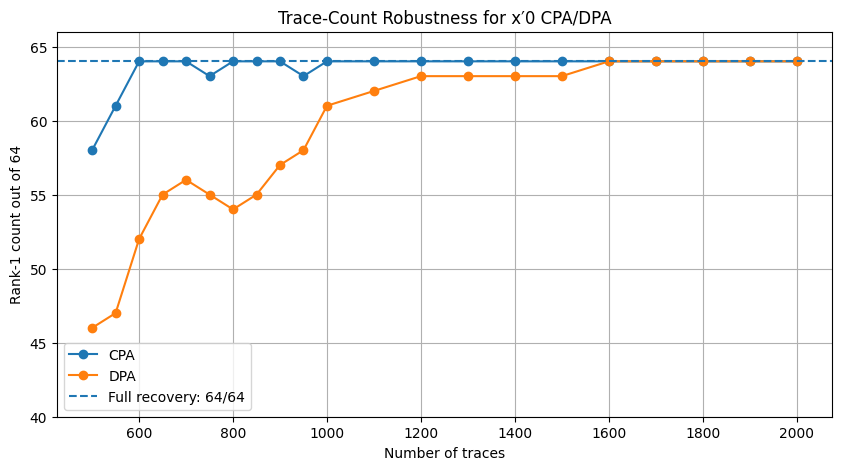

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x0_cpa_dpa\figures\fig2_x0_trace_count_robustness.png


In [17]:
robust_path = RESULTS_DIR / "x0_trace_count_robustness_summary_stride1.csv"
robust = pd.read_csv(robust_path)

plt.figure(figsize=(10, 5))

for method in ["CPA", "DPA"]:
    df = robust[robust["method"] == method].sort_values("N_USE")
    plt.plot(
        df["N_USE"],
        df["rank1_count_out_of_64"],
        marker="o",
        label=method
    )

plt.axhline(64, linestyle="--", label="Full recovery: 64/64")

plt.title("Trace-Count Robustness for x′0 CPA/DPA")
plt.xlabel("Number of traces")
plt.ylabel("Rank-1 count out of 64")
plt.ylim(40, 66)
plt.grid(True)
plt.legend()

out = FIG_DIR / "fig2_x0_trace_count_robustness.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out)

,method,rank1_count_out_of_64,average_true_rank,test
0,CPA,64,1.000000,Normal
1,DPA,64,1.000000,Normal
2,CPA,9,4.468750,Shuffled nonce
3,DPA,9,4.421875,Shuffled nonce


<Figure size 800x500 with 0 Axes>

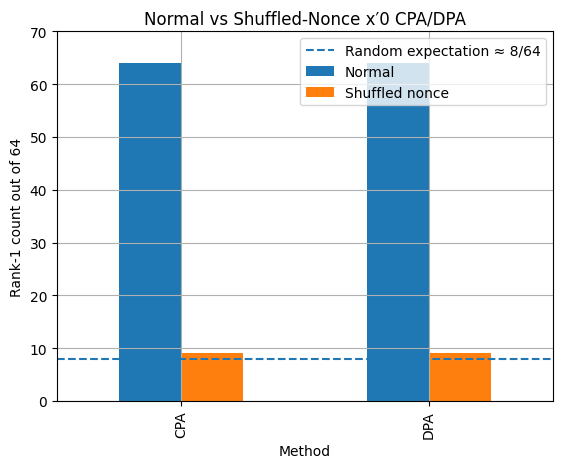

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x0_cpa_dpa\figures\fig3_x0_normal_vs_shuffle.png


In [18]:
normal_path = RESULTS_DIR / "x0_clean_cpa_dpa_summary_N50000_samples0_12000_stride1.csv"
shuffle_path = RESULTS_DIR / "x0_shuffle_sanity_summary_N50000.csv"

normal = pd.read_csv(normal_path)
shuffle = pd.read_csv(shuffle_path)

normal_small = normal[["method", "rank1_count_out_of_64", "average_true_rank"]].copy()
normal_small["test"] = "Normal"

shuffle_small = shuffle[["method", "rank1_count_out_of_64", "average_true_rank"]].copy()
shuffle_small["test"] = "Shuffled nonce"

compare = pd.concat([normal_small, shuffle_small], ignore_index=True)

display(compare)

plot_df = compare.pivot(index="method", columns="test", values="rank1_count_out_of_64")

plt.figure(figsize=(8, 5))
plot_df.plot(kind="bar")

plt.title("Normal vs Shuffled-Nonce x′0 CPA/DPA")
plt.xlabel("Method")
plt.ylabel("Rank-1 count out of 64")
plt.ylim(0, 70)
plt.axhline(8, linestyle="--", label="Random expectation ≈ 8/64")
plt.grid(True)
plt.legend()

out = FIG_DIR / "fig3_x0_normal_vs_shuffle.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out)

## 9. Interpretation guide

For x′0 there are **8 candidates** per bit position.

Random expectation:
```text
Rank-1 count ≈ 8 / 64
Average true rank ≈ 4.5
```

Strong result:
```text
Rank-1 count much larger than 8 / 64
Average true rank close to 1
```

Ideal result:
```text
Rank-1 count = 64 / 64
Average true rank = 1.0
```

After x′0 succeeds:
1. Run robustness test.
2. Run shuffled-nonce sanity check.
3. Move to x′1 CPA/DPA.